# Problem Statement : Medical Insurence Premium


- A health insurance company wants to predict the insurance premium charges based on various factors such as age, sex, BMI (Body Mass Index), children (number of dependents), smoker status, and region. These factors contribute to the final premium amount charged to an individual.
- The company aims to build a multiple linear regression model to predict the insurance charges based on the mentioned independent variables. By understanding the relationship between the features and the charges, they can make informed decisions regarding policy pricing.
- The company seeks to develop a multiple linear regression model to predict insurance premiums based on factors like age, sex, BMI, children, smoker status, and region for more accurate pricing.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [25]:
data = pd.read_csv('insurance.csv')

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Inspection

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
data.shape

(1338, 7)

In [7]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [26]:
data.duplicated().sum()

1

In [17]:
# Show ALL instances of duplicated rows (both the original and duplicate)
data[data.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [20]:
# Show only the duplicate row (the second occurrence)
data[data.duplicated(keep='last')]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631


In [27]:
# data = data.drop_duplicates(keep='last')
# data.duplicated().sum()

# EDA

## Univariate Analysis

## Numerical Columns

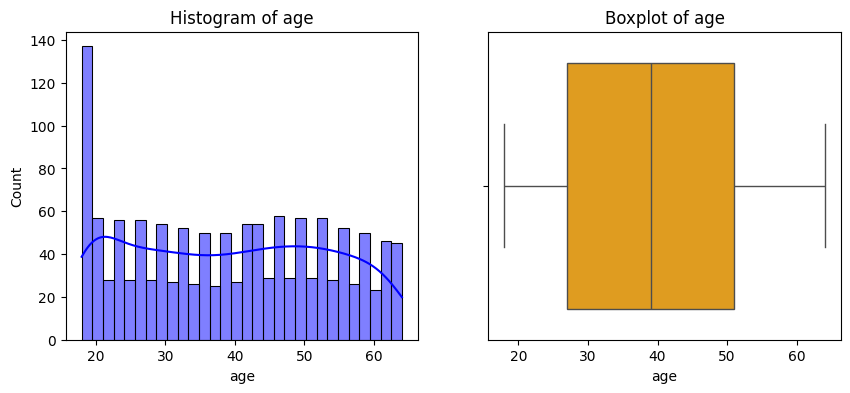

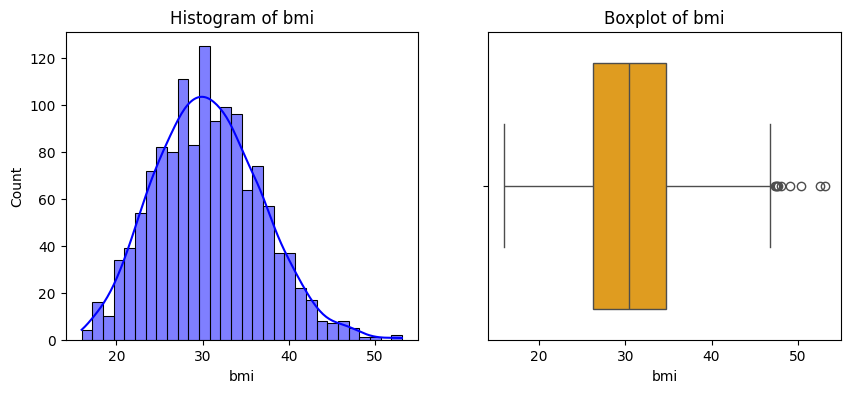

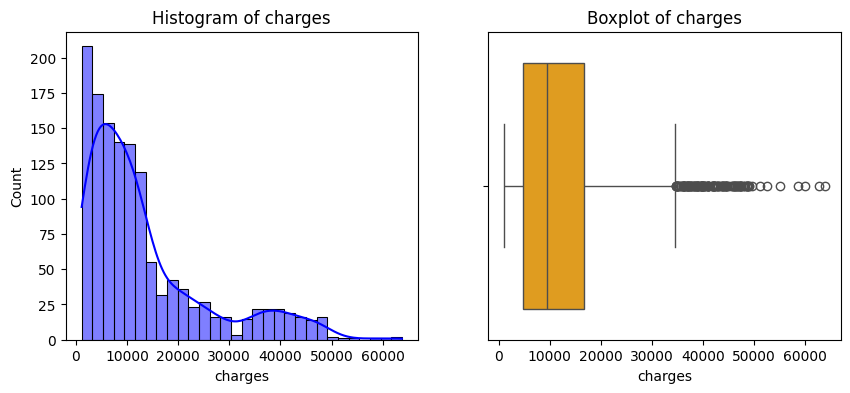

In [33]:
# Plot histograms and boxplots
numeric_features = ['age', 'bmi','charges'] # 'children'

for feature in numeric_features:
    plt.figure(figsize=(10, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data[feature], kde=True, bins=30, color='blue')
    plt.title(f'Histogram of {feature}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[feature], color='orange')
    plt.title(f'Boxplot of {feature}')

    plt.show()


## Categorical Columns

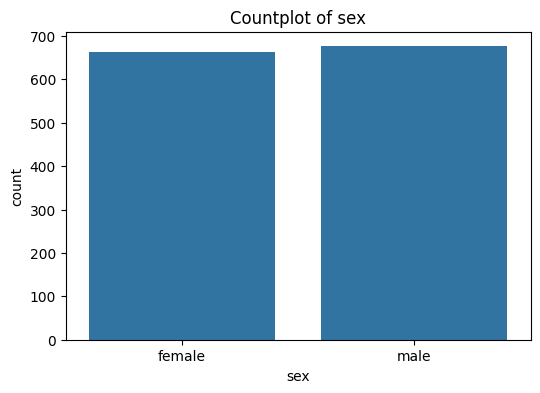

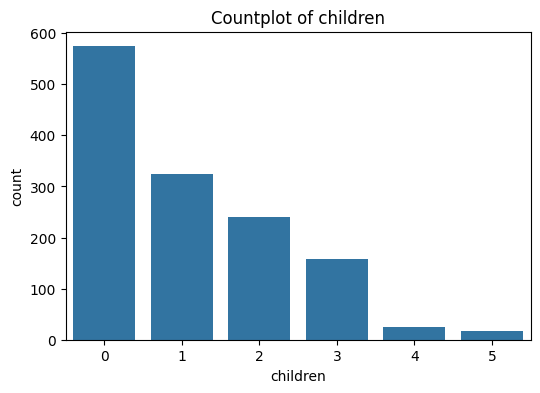

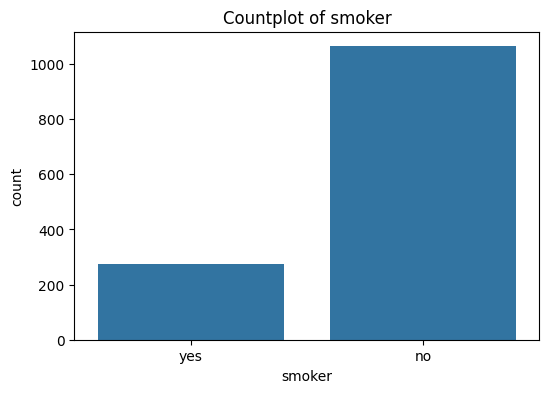

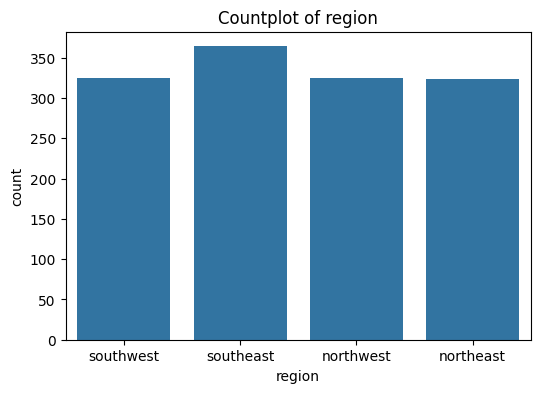

In [34]:
# Plot bar plots
categorical_features = ['sex','children', 'smoker', 'region']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=data, x=feature)
    plt.title(f'Countplot of {feature}')
    plt.show()

## Bivariate Analysis

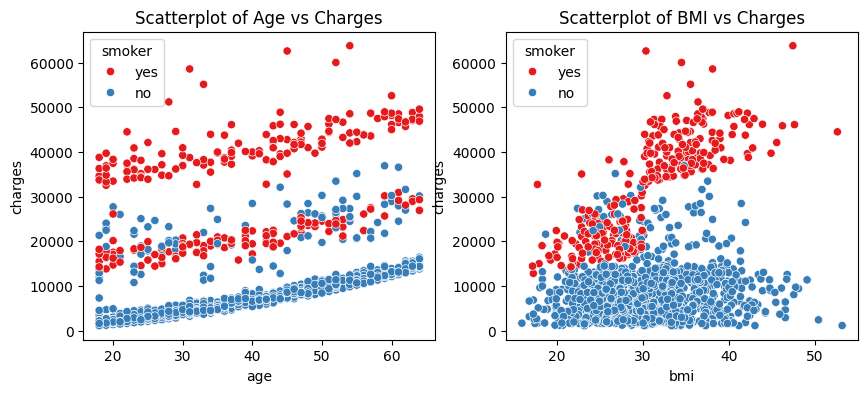

In [36]:
# Scatterplots for charges vs other numeric features
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
sns.scatterplot(data=data, x='age', y='charges', hue='smoker', palette='Set1')
plt.title(f'Scatterplot of Age vs Charges')

plt.subplot(1,2,2)
sns.scatterplot(data=data, x='bmi', y='charges', hue='smoker', palette='Set1')
plt.title(f'Scatterplot of BMI vs Charges')

plt.show()

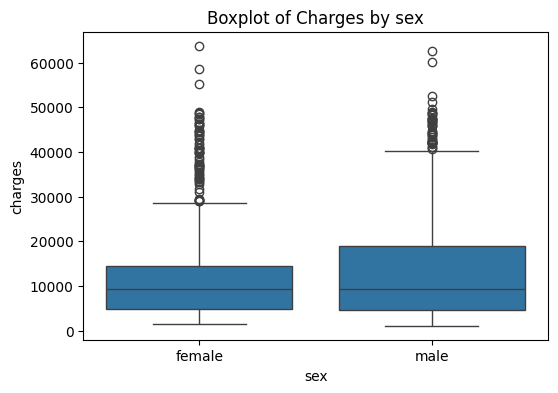

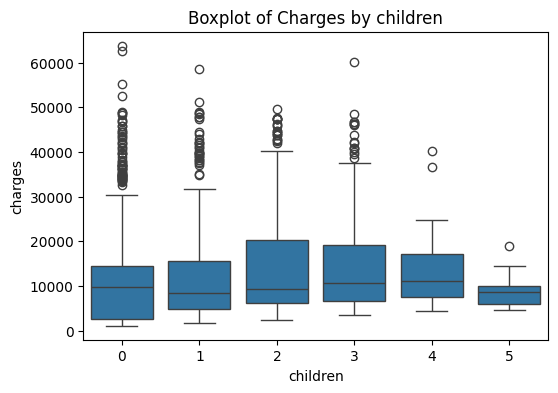

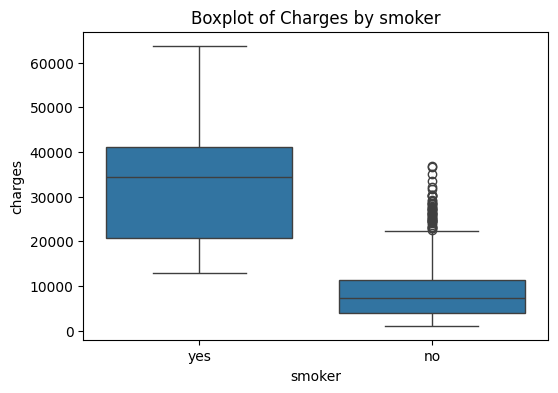

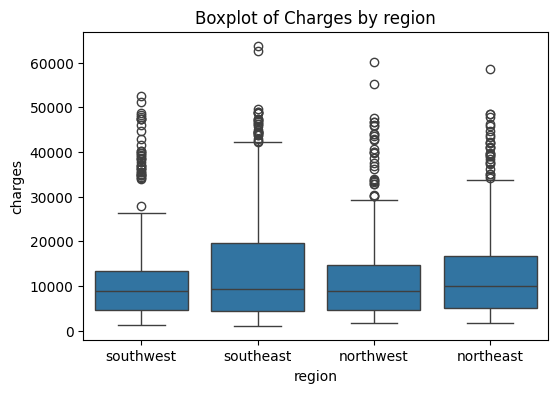

In [38]:
# Boxplots for charges across categories
categorical_features = ['sex','children','smoker', 'region']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data, x=feature, y='charges')
    plt.title(f'Boxplot of Charges by {feature}')
    plt.show()

## One hot encoding

In [35]:
from sklearn.preprocessing import OneHotEncoder

In [36]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [58]:
# apply one hot encoding and replace data
encoded_df = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True).astype(int)
encoded_df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0


## Split Data

In [40]:
X = encoded_df.drop(['charges'], axis = 1)
y = encoded_df['charges']

In [41]:
X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,0,1,0,0,1
1,18,33,1,1,0,0,1,0
2,28,33,3,1,0,0,1,0
3,33,22,0,1,0,1,0,0
4,32,28,0,1,0,1,0,0


In [42]:
y.head()

0    16884
1     1725
2     4449
3    21984
4     3866
Name: charges, dtype: int64

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 8)
(268, 8)
(1070,)
(268,)


## Build Multiple Linear Regression Model

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [47]:
y_pred = lr.predict(X_test)

In [48]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 33566439.73530042


The `Mean Squared Error (MSE)` value of 32,201,893.45 indicates the average squared difference between actual and predicted insurance charges. A large MSE suggests the model might be underperforming or not well-tuned.

## Steps to Improve the Model:

1. `Feature Engineering`: Check for missing important variables or transformations (e.g. log transformation).
2. `Data Scaling`: Ensure numerical features like age, bmi, etc., are scaled properly.
3. `Outlier Treatment`: Remove or handle extreme values that may skew predictions.
4. Try feature selection or regularization.

In [59]:
encoded_df['charges'] = np.log(encoded_df['charges'])
encoded_df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,9.734122,0,1,0,0,1
1,18,33,1,7.452982,1,0,0,1,0
2,28,33,3,8.400435,1,0,0,1,0
3,33,22,0,9.998070,1,0,1,0,0
4,32,28,0,8.259976,1,0,1,0,0


In [60]:
X = encoded_df.drop(['charges'], axis = 1)
y = encoded_df['charges']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [63]:
y_pred = lr.predict(X_test)

In [64]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.17538221423345815


- log charges are not usefull so to see original data do exponential.

In [65]:
y_pred_original = np.exp(y_pred)
y_pred_original

array([ 9128.1666751 ,  5639.57500524, 65786.56671627,  9094.57444132,
       13996.42513666,  5905.34211737,  2825.65561898, 15025.05936822,
        3800.67103657, 10498.49014355, 22900.27634943,  7477.24274184,
        4430.26717796, 49914.33075403, 59438.59217168, 44593.9941072 ,
       11505.68592566, 42612.94527384,  7823.461013  , 32045.10123173,
        4852.20721692,  7695.80001187,  2735.54625891,  4173.99805643,
       11702.48355786, 11355.54272349, 12844.83863148,  5469.72297719,
        9909.23382323,  2607.57520959,  8641.35031612, 11736.22457855,
        3286.72928119,  5219.38521198,  3813.88260887,  8519.25668641,
        3278.25333097,  7254.58365842, 46560.97223514, 26775.25551297,
        4555.09715127,  3604.32840072, 12286.45544434, 10753.83917254,
        5614.23630524, 11337.67080109,  4228.98827721,  4402.76832724,
       40950.0983214 ,  5460.84706958, 14234.03411943,  2821.81443034,
        8239.77999042,  2831.33972686, 10118.4437855 , 11061.84967571,
      